<a href="https://colab.research.google.com/github/eklavya0948-max/electric-load-forecasting-weather-time/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is linear regression?
Linear regression is model type which is used to relate one independent variable lets say X which is our input value to an dependent variable lets say Y which is output of model in a straight line to predict a continious target varaible from a dataset.

In this project, Linear Regression is used to predict electrical load using
meteorological and time-based factors such as temperature, humidity, hour,
day of week, and month.


import cleaned dataset


In [2]:
from google.colab import files
uploaded = files.upload()

Saving cleaned data.csv to cleaned data.csv


In [3]:
# To load data
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned data.csv")
# To view data
df.head()

,datetime,temperature,humidity,load,hour,day_of_week,month
0,2021-01-01 01:00:00,65,90,1967.388015,1,4,1
1,2021-01-01 02:00:00,65,90,1967.388015,2,4,1
2,2021-01-01 03:00:00,65,90,1967.388015,3,4,1
3,2021-01-01 04:00:00,78,49,2442.607331,4,4,1
4,2021-01-01 05:00:00,78,49,2756.205522,5,4,1


To define features and load

In [22]:
# X(input): features
# Y(output): load
X = df[["temperature","humidity","hour","day_of_week","month"]]
y = df["load"]

Training test split

Using 80% dataset for training and 20% for testing . You can change training dataset by  changing test size.


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Linear Regression model


In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Making Predictions


In [25]:
y_pred = model.predict(X_test)

Evaluating model using 2 statistical tools

1. MAE( Mean Absolute Error)

  It measures average size of error

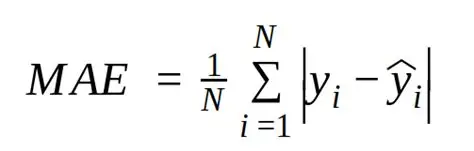

Here ,


 $y_i$= actual value

 $\hat{y}_i$= predicted value

 N= No. of data ppints

 2. RMSE ( Root Mean Squared Error )


RMSE calculates the square root of the average of squared differences between predicted and actual values.

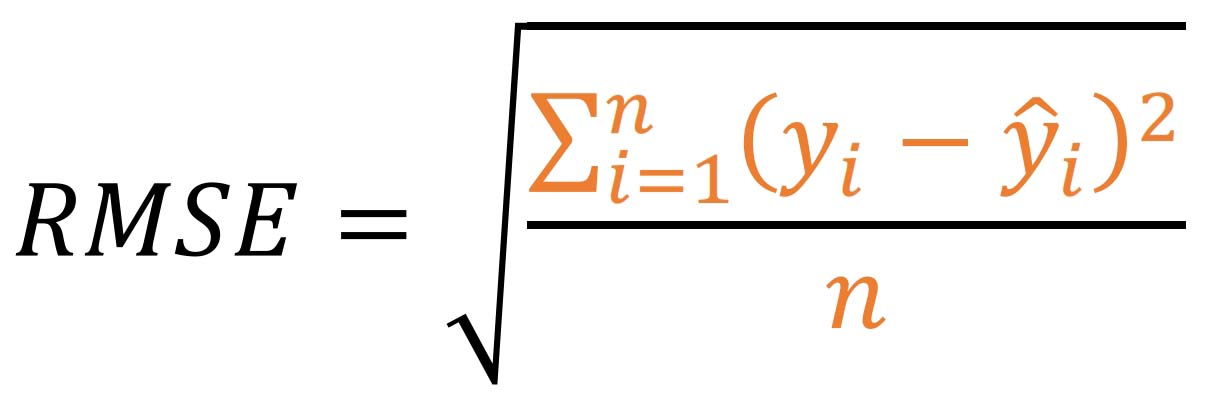




In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 932.3410683416072
RMSE: 1145.0537821876353


Plotting Actual vs Predicted load graph

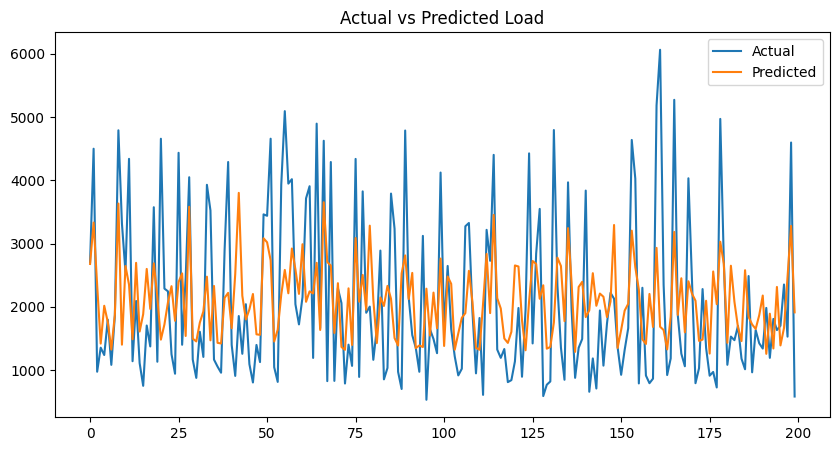

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Load")
plt.show()

Our maximum approx. load value was 6306 KW in practical cases generally Transformer Rating is ≈1.25×Maximum Load
Since we are taking substation data Rating is ≈1.25× 6303≈ 7.9 KW. Our mae result means that our average predicted value is 944 KW more or 944 KW less than the actual value . Our RMSE>MAE which tells that there is large error in prediction since it punishes large error harshly.

So lets try to increase our accuracy of model . We know that load follows certain patterns like repeating itself pereodicaly . So lets add lag features so that our model can learn past patterns of electricity consumptions

In [28]:
# What are lag features?
# Lag features are previous time step values used as input features in a model.
# They help the model understand how past electricity load affects the current load.

# What is a time step in lag features?
# A time step refers to the interval between two data points.
# In this project the time step is one hour, meaning the load is recorded every hour.

# Example:
# lag_1 means load from previous hour
# lag_2 means load from 2 hours ago
# lag_7 means load from 7 hours ago
# lag_24 -> load from the same hour on the previous day

df["load_lag1"] = df["load"].shift(1)
df["load_lag2"] = df["load"].shift(2)
df["load_lag3"] = df["load"].shift(3)
df["load_lag6"] = df["load"].shift(6)
df["load_lag12"] = df["load"].shift(12)
df["load_lag24"] = df["load"].shift(24)
df["load_lag48"] = df["load"].shift(48)
df["load_lag168"] = df["load"].shift(168)

/tmp/ipykernel_316/274130346.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["load_lag1"] = df["load"].shift(1)
/tmp/ipykernel_316/274130346.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["load_lag2"] = df["load"].shift(2)
/tmp/ipykernel_316/274130346.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

To handle missing values

In [29]:
df = df.dropna()

Redefining X and Y

In [30]:
X = df[['temperature',
        'humidity',
        'hour',
        'day_of_week',
        'month',
        'load_lag1',
        'load_lag2',
        'load_lag3',
        'load_lag6',
        'load_lag12',
        'load_lag24',
        'load_lag48',
        'load_lag168']]

y = df['load']

Retraining model with newly defined features

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

Evaluating new model

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("MAE:",mae)
print("RMSE:",rmse)

MAE: 249.04383795166137
RMSE: 412.25568347866783


Our new MAE and RMSE results are clearly far low than are previous value which a huge leap in our model accuracy. Low RMSE shows that there isnt any large error in predicted data.

Plotting improved models actual vs predicted graph.

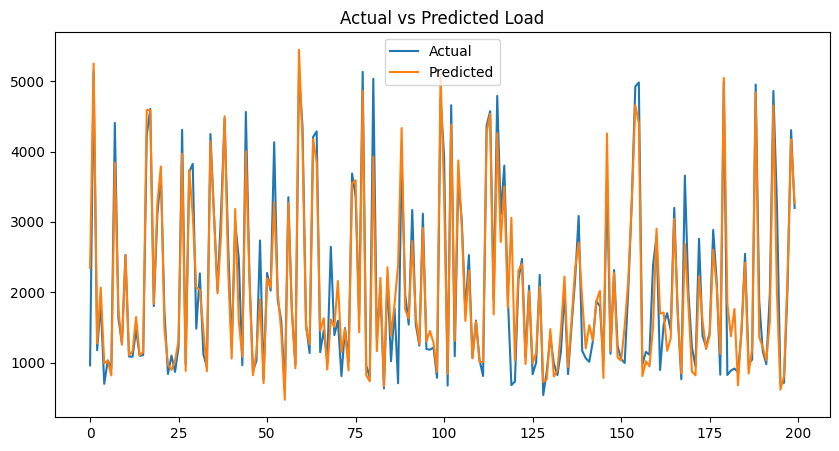

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Load")
plt.show()